In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')
import joblib

In [7]:
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, col='avg_monthly_price'):
        self.col = col
    def fit(self, X, y=None):
        Q1 = X[self.col].quantile(0.25)
        Q3 = X[self.col].quantile(0.75)
        IQR = Q3 - Q1
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        return self
    def transform(self, X):
        df = X.copy()
        df[self.col] = df[self.col].clip(lower=self.lower_, upper=self.upper_)
        return df

In [8]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, col='avg_monthly_price'):
        self.col = col
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        df = X.copy()
        df['month']     = df.index.month
        df['quarter']   = df.index.quarter
        df['year']      = df.index.year
        df['trend']     = np.arange(len(df))
        df['lag_1']     = df[self.col].shift(1)
        df['lag_2']     = df[self.col].shift(2)
        df['lag_3']     = df[self.col].shift(3)
        df['roll_3']    = df[self.col].shift(1).rolling(3).mean()
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        df['momentum']  = df[self.col].diff(1)
        df.dropna(inplace=True)
        return df

In [17]:
artifact   = joblib.load("price_model.joblib")
model      = artifact['model']
last_3     = list(artifact['last_3'])
last_trend = artifact['last_trend']
last_date  = artifact['last_date']
FEATURES = model.named_steps['scaler'].feature_names_in_.tolist()
TARGET     = 'avg_monthly_price'

In [25]:
future_dates = pd.date_range(
    start   = last_date + pd.DateOffset(months=1),
    periods = 60,
    freq    = 'MS'
)
 
predictions = []
# Seed with last 3 known prices on correct dates
seed_dates = pd.date_range(end=last_date, periods=3, freq='MS')
history    = pd.Series(list(last_3), index=seed_dates, name='avg_monthly_price')
 
engineer   = preprocess.named_steps['engineer']
 
for i, date in enumerate(future_dates):
    # Give engineer enough rows to compute lag_3 and roll_3 (needs 3 history rows)
    df_window = pd.DataFrame(
        {'avg_monthly_price': list(history.iloc[-3:]) + [history.iloc[-1]]},
        index = list(history.index[-3:]) + [date]
    )
 
    df_eng = engineer.transform(df_window)
 
    # Fix trend — engineer restarts from 0, we need the real global trend
    df_eng['trend'] = last_trend + i + 1
 
    pred = model.predict(df_eng[FEATURES].iloc[[-1]])[0]
    predictions.append(pred)
    history.loc[date] = pred
 

In [26]:
df_future = pd.DataFrame({'predicted_price': predictions}, index=future_dates)
print("\n Next 12 Months Predictions")
print("─" * 35)
print(df_future.to_string())
 


 Next 12 Months Predictions
───────────────────────────────────
            predicted_price
2025-10-01     15223.938433
2025-11-01     15208.559901
2025-12-01     15200.742018
2026-01-01     15170.504568
2026-02-01     15145.989332
2026-03-01     15122.629526
2026-04-01     15092.332407
2026-05-01     15062.932211
2026-06-01     15034.608360
2026-07-01     15001.963715
2026-08-01     14974.722548
2026-09-01     14953.779878
2026-10-01     14933.046288
2026-11-01     14920.334090
2026-12-01     14913.919266
2027-01-01     14885.562031
2027-02-01     14862.883159
2027-03-01     14841.348867
2027-04-01     14812.869952
2027-05-01     14785.279856
2027-06-01     14758.758080
2027-07-01     14727.907525
2027-08-01     14702.452500
2027-09-01     14683.288058
2027-10-01     14664.324818
2027-11-01     14653.375126
2027-12-01     14648.714997
2028-01-01     14622.104684
2028-02-01     14601.164993
2028-03-01     14581.362176
2028-04-01     14554.607065
2028-05-01     14528.733134
2028-06-01 

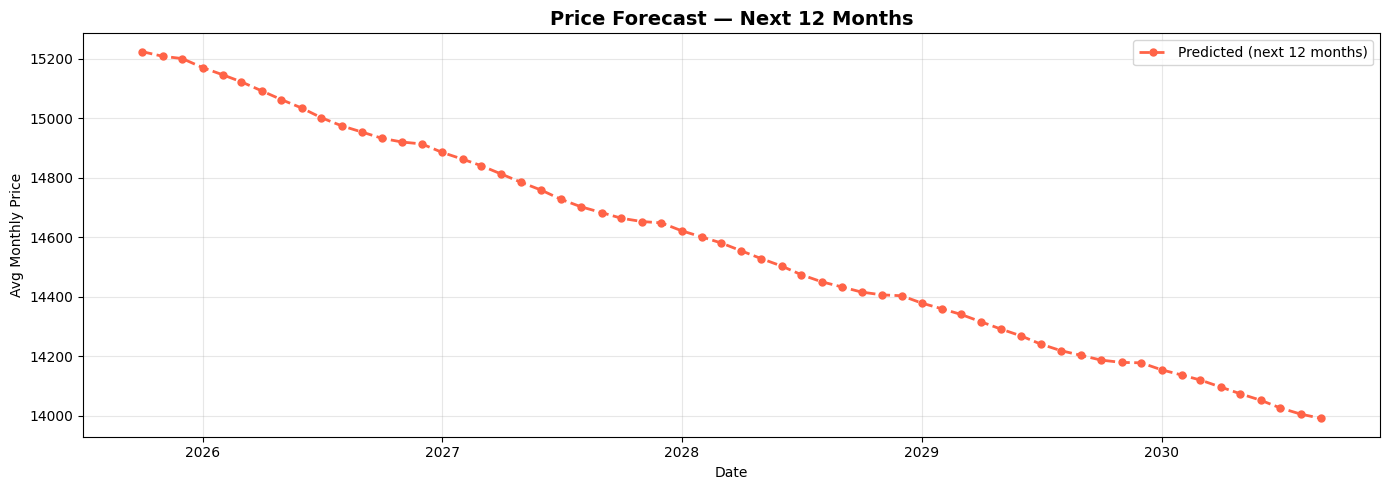


Plot saved → forecast_plot.png


In [27]:
plt.figure(figsize=(14, 5))
plt.plot(df_future.index, df_future['predicted_price'],
         color='tomato', linewidth=2, marker='o', markersize=5,
         linestyle='--', label='Predicted (next 12 months)')
plt.title('Price Forecast — Next 12 Months', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Avg Monthly Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("forecast_plot.png", dpi=150)
plt.show()
print("\nPlot saved → forecast_plot.png")
 

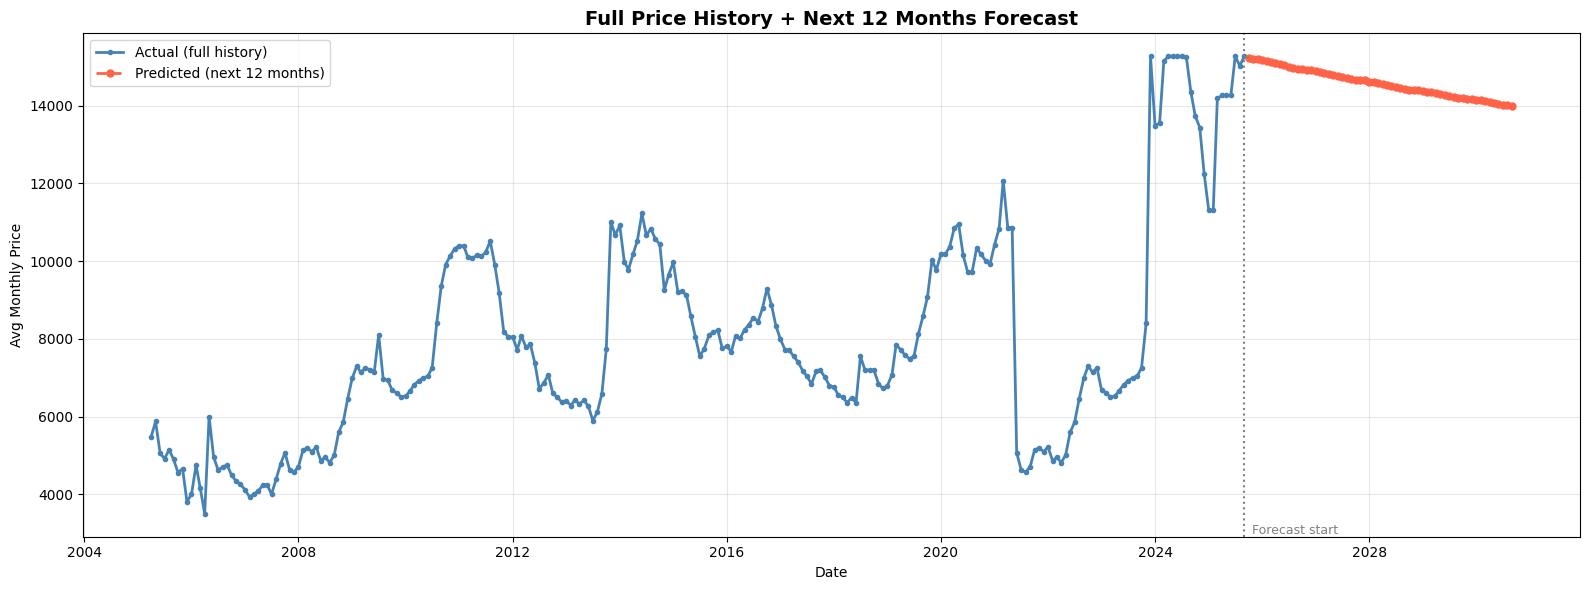

Plot saved → full_forecast_plot.png


In [28]:
fig, ax = plt.subplots(figsize=(16, 6))
 
# All original actual data
ax.plot(df_feat.index, df_feat[TARGET].values,
        color='steelblue', linewidth=2, marker='o', markersize=3,
        label='Actual (full history)')
 
# Next 12 months predicted
ax.plot(df_future.index, df_future['predicted_price'],
        color='tomato', linewidth=2, marker='o', markersize=5,
        linestyle='--', label='Predicted (next 12 months)')
 
# Connect actual end to forecast start
ax.plot([df_feat.index[-1], df_future.index[0]],
        [df_feat[TARGET].iloc[-1], df_future['predicted_price'].iloc[0]],
        color='gray', linewidth=1, linestyle='--')
 
# Forecast start line
ax.axvline(x=df_feat.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.text(df_feat.index[-1], ax.get_ylim()[0],
        '  Forecast start', color='gray', fontsize=9, va='bottom')
 
ax.set_title('Full Price History + Next 12 Months Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Monthly Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("full_forecast_plot.png", dpi=150)
plt.show()
print("Plot saved → full_forecast_plot.png")
 


 Next 60 Months Predictions
-----------------------------------
            predicted_price
2025-10-01     15223.938433
2025-11-01     15208.559901
2025-12-01     15200.742018
2026-01-01     15170.504568
2026-02-01     15145.989332
2026-03-01     15122.629526
2026-04-01     15092.332407
2026-05-01     15062.932211
2026-06-01     15034.608360
2026-07-01     15001.963715
2026-08-01     14974.722548
2026-09-01     14953.779878
2026-10-01     15199.227445
2026-11-01     15191.951582
2026-12-01     15191.277142
2027-01-01     15140.005474
2027-02-01     15118.861531
2027-03-01     15096.966714
2027-04-01     15059.969237
2027-05-01     15030.726824
2027-06-01     15003.477034
2027-07-01     14966.661641
2027-08-01     14944.344330
2027-09-01     14930.194754
2027-10-01     15175.281147
2027-11-01     15176.067661
2027-12-01     15182.501142
2028-01-01     15110.299852
2028-02-01     15092.510438
2028-03-01     15072.073325
2028-04-01     15028.408807
2028-05-01     14999.323394
2028-06-01 

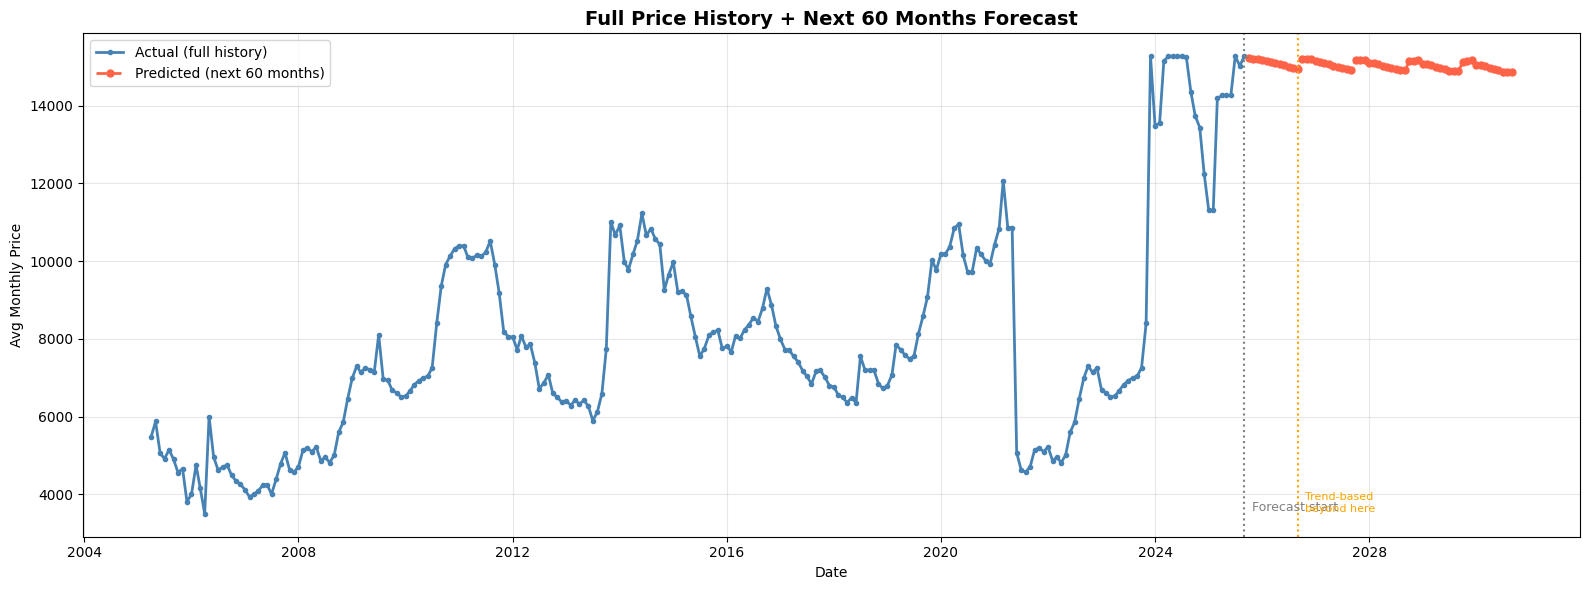

Plot saved -> full_forecast_plot.png


In [30]:
FORECAST_MONTHS = 60       # change to 24, 36, 60 as needed
SAFE_HORIZON    = 12        # lag-based iterative limit
 
future_dates = pd.date_range(
    start   = last_date + pd.DateOffset(months=1),
    periods = FORECAST_MONTHS,
    freq    = 'MS'
)
 
predictions = []
seed_dates  = pd.date_range(end=last_date, periods=3, freq='MS')
history     = pd.Series(list(last_3), index=seed_dates, name=TARGET)
engineer    = preprocess.named_steps['engineer']
 
for i, date in enumerate(future_dates):
 
    if i < SAFE_HORIZON:
        # Iterative lag-based (accurate, short horizon)
        df_window = pd.DataFrame(
            {TARGET: list(history.iloc[-3:]) + [history.iloc[-1]]},
            index = list(history.index[-3:]) + [date]
        )
    else:
        # Beyond safe horizon — anchor lags on same month 12 steps back
        # avoids compounding error / straight-line drift
        lag_anchor = predictions[i - 12]
        df_window = pd.DataFrame(
            {TARGET: [lag_anchor, lag_anchor, lag_anchor, lag_anchor]},
            index = pd.date_range(end=date, periods=4, freq='MS')
        )
 
    df_eng          = engineer.transform(df_window)
    df_eng['trend'] = last_trend + i + 1
    pred = model.predict(df_eng[FEATURES].iloc[[-1]])[0]
    predictions.append(pred)
    history.loc[date] = pred
 
df_future = pd.DataFrame({'predicted_price': predictions}, index=future_dates)
print(f"\n Next {FORECAST_MONTHS} Months Predictions")
print("-" * 35)
print(df_future.to_string())
 
# ── Plot : Full original data + forecast ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
 
ax.plot(df_feat.index, df_feat[TARGET].values,
        color='steelblue', linewidth=2, marker='o', markersize=3,
        label='Actual (full history)')
 
ax.plot(df_future.index, df_future['predicted_price'],
        color='tomato', linewidth=2, marker='o', markersize=5,
        linestyle='--', label=f'Predicted (next {FORECAST_MONTHS} months)')
 
ax.plot([df_feat.index[-1], df_future.index[0]],
        [df_feat[TARGET].iloc[-1], df_future['predicted_price'].iloc[0]],
        color='gray', linewidth=1, linestyle='--')
 
ax.axvline(x=df_feat.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.text(df_feat.index[-1], df_feat[TARGET].min(),
        '  Forecast start', color='gray', fontsize=9, va='bottom')
 
# Mark safe vs extended horizon boundary
if FORECAST_MONTHS > SAFE_HORIZON:
    boundary = future_dates[SAFE_HORIZON - 1]
    ax.axvline(x=boundary, color='orange', linestyle=':', linewidth=1.5)
    ax.text(boundary, df_feat[TARGET].min(),
            '  Trend-based\n  beyond here', color='orange', fontsize=8, va='bottom')
 
ax.set_title(f'Full Price History + Next {FORECAST_MONTHS} Months Forecast',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Avg Monthly Price')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("full_forecast_plot.png", dpi=150)
plt.show()
print("Plot saved -> full_forecast_plot.png")
 